# Resume-to-Job Match Assistant -- LangGraph + Google Gemini

An agentic career advisor. A resume and a job description go in; a fit score, a gap
analysis and either a recruiter message, a resume rewrite or a learning roadmap come out.

The agent never answers in one shot. Eight agents each do one job, and a **decision router**
picks which of the three closing agents runs, based on a score that was calculated in
Python rather than guessed by the model.

```
START -> input_validator
              |
   missing ---+--- complete
      |             |
      |       resume_parser -> jd_parser -> skill_matching -> gap_analysis
      |                                                            |
      |                                                       fit_score
      |                                                            |
      |          score >= 80 ------------ 60-79 ------------ below 60
      |               |                     |                     |
      |        cover_letter      resume_improvement      learning_roadmap
      |               |                     |                     |
      +---------------+----- final_recommendation ----------------+
                                    |
                                   END
```

Concepts demonstrated: **state** with a reducer, **10 nodes**, **2 conditional edges**,
**3 deterministic tools**, **structured output**, and **checkpointed memory**.

### How the tasks map to the handout

| Notebook | Handout | What you build |
| --- | --- | --- |
| Task 1 | Task 1 | Install the libraries |
| Task 2 | Task 2 | Configure Gemini |
| Task 3 | Task 3 | `JobMatchState` |
| Task 4 | Section 6 | The three tools -- they must exist before the nodes call them |
| Task 5 | Task 4 | The ten nodes |
| Task 6 | Task 5 | Conditional routing |
| Task 7 | Task 6 | Compile the graph |
| Task 8 | Task 7 | Test against three job descriptions |

## Task 1 -- Install the libraries

`langgraph` builds the graph, `langchain-google-genai` talks to Gemini. The `-q` keeps
Colab's output short.

In [1]:
!pip install -q langgraph langchain langchain-google-genai

## Task 2 -- Configure Gemini

A local `.env` file is tried first, so restarting the kernel does not mean retyping the key.
In Colab there is no `.env`, so it falls through to `getpass` -- which keeps the key off the
screen, and out of the notebook when you share it.

In VS Code the `getpass` box opens at the **top-centre of the window**, like the command
palette. Clicking anywhere else dismisses it and the cell waits forever, so watch for it.

The model itself is built further down in `get_llm()`, lazily -- so every cell up to Task 7
runs whether or not the key is valid, and only the actual screening needs the network.

In [2]:
import os
from getpass import getpass

try:
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

if not os.getenv("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = getpass("Enter your Google AI Studio API key: ")

print("key loaded:", bool(os.getenv("GOOGLE_API_KEY")))

key loaded: True


## Task 3 -- The state

`JobMatchState` is the shared memory. Every node receives it and returns **only the keys it
changed**; LangGraph merges the result in.

Plain keys are overwritten. `history` is different -- the `operator.add` annotation makes it
a *reducer*, so lists are concatenated instead of replaced. That one annotation is the whole
difference between an agent that forgets the last job and one that can compare roles.

Note that `total=False` lets nodes return partial dicts without the type checker objecting.

In [3]:
from __future__ import annotations

import operator
import os
from typing import Annotated, List, Optional, TypedDict


from langchain_core.prompts import ChatPromptTemplate
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, START, StateGraph
from pydantic import BaseModel, Field







# Overridable so the project keeps working as new Gemini versions ship.
CHAT_MODEL = os.getenv("GEMINI_CHAT_MODEL", "gemini-2.5-flash")

In [4]:
class JobMatchState(TypedDict, total=False):
    """Shared memory every node reads from and writes to.

    A node returns a partial dict; LangGraph merges it into the state. Plain keys
    are overwritten, but ``history`` carries the ``operator.add`` reducer, so its
    lists are concatenated instead -- that is what lets one thread build up a
    record of every job the candidate has been screened against.
    """

    # inputs
    resume_text: str
    job_description: str
    # agent 1
    resume_available: bool
    jd_available: bool
    missing_information: List[str]
    # agents 2 and 3
    parsed_resume: Optional[dict]
    parsed_jd: Optional[dict]
    # agent 4
    matched_skills: List[str]
    partially_matched_skills: List[str]
    missing_skills: List[str]
    # agents 5 and 6
    gap_analysis: Optional[str]
    fit_score: Optional[int]
    fit_level: Optional[str]
    apply_recommendation: Optional[str]
    score_breakdown: Optional[dict]
    # the three branches
    cover_letter: Optional[str]
    resume_improvement_suggestions: Optional[str]
    learning_roadmap: Optional[str]
    # the closing node
    final_recommendation: Optional[str]
    history: Annotated[List[str], operator.add]

## Task 4 -- The three tools

A tool here is just a Python function. These three deliberately keep work *away* from the
LLM:

1. **`normalize_skill`** -- the JD says `CPI`, the resume says `SAP Integration Suite`. Without
   normalisation that is a false gap, and the candidate loses points for a skill they have.
2. **`calculate_fit_score`** -- weighted arithmetic, not a prompt. Same inputs, same number,
   every run, and `score_breakdown` shows exactly where the points came from.
3. **`generate_learning_plan`** -- a curated 30/60/90 day schedule, so the roadmap cites real
   SAP learning journeys instead of invented course names.

The taxonomy below is the SAP-specific part of section 12 in the handout.

### The skill taxonomy

`SKILL_SYNONYMS` maps every spelling onto one canonical name, and the last line folds the
canonical names back in as keys so `SAP BTP` normalises to itself.

`SAP_PLATFORM_SKILLS` and `GENAI_SKILLS` are the two buckets the scoring rubric weights
separately -- 20 points each.

In [5]:
from __future__ import annotations

import re
from typing import Dict, Iterable, List, Sequence, Set

from langchain_core.tools import tool as as_tool

In [6]:
# Every spelling a resume or job ad might use, mapped to one canonical name.
# Without this, "CPI" in the JD and "SAP Integration Suite" in the resume look
# like two different skills, and the candidate is marked down for a gap that
# does not exist.
SKILL_SYNONYMS: Dict[str, str] = {
    # --- SAP platform ---
    "btp": "SAP BTP",
    "sap business technology platform": "SAP BTP",
    "business technology platform": "SAP BTP",
    "cpi": "SAP Integration Suite",
    "sap cpi": "SAP Integration Suite",
    "cloud integration": "SAP Integration Suite",
    "integration suite": "SAP Integration Suite",
    "pi po": "SAP Integration Suite",
    "cap": "SAP CAP",
    "cloud application programming model": "SAP CAP",
    "cap applications": "SAP CAP",
    "rap": "SAP RAP",
    "restful application programming model": "SAP RAP",
    "abap": "ABAP",
    "abap cloud": "ABAP Cloud",
    "hana": "SAP HANA Cloud",
    "sap hana": "SAP HANA Cloud",
    "hana cloud": "SAP HANA Cloud",
    "hana vector engine": "SAP HANA Cloud Vector Engine",
    "vector engine": "SAP HANA Cloud Vector Engine",
    "bpa": "SAP Build Process Automation",
    "build process automation": "SAP Build Process Automation",
    "workflow management": "SAP Build Process Automation",
    "build apps": "SAP Build Apps",
    "fiori": "SAP Fiori",
    "ui5": "SAP Fiori",
    "s4hana": "SAP S/4HANA",
    "s 4hana": "SAP S/4HANA",
    "successfactors": "SAP SuccessFactors",
    # --- SAP AI ---
    "ai core": "SAP AI Core",
    "sap ai core": "SAP AI Core",
    "ai launchpad": "SAP AI Launchpad",
    "sap gen ai": "SAP Generative AI Hub",
    "sap genai": "SAP Generative AI Hub",
    "gen ai hub": "SAP Generative AI Hub",
    "genai hub": "SAP Generative AI Hub",
    "generative ai hub": "SAP Generative AI Hub",
    "joule": "SAP Joule",
    "joule studio": "SAP Joule",
    "sap business ai": "SAP Business AI",
    # --- Generative / agentic AI ---
    "genai": "Generative AI",
    "gen ai": "Generative AI",
    "llm": "Generative AI",
    "llms": "Generative AI",
    "large language models": "Generative AI",
    "retrieval augmented generation": "RAG",
    "graph rag": "GraphRAG",
    "agentic ai": "Agentic AI",
    "ai agents": "Agentic AI",
    "agentic workflows": "Agentic AI",
    "multi agent": "Agentic AI",
    "langgraph": "LangGraph",
    "langchain": "LangChain",
    "prompt engineering": "Prompt Engineering",
    "vector db": "Vector Database",
    "vector database": "Vector Database",
    "vector store": "Vector Database",
    "embeddings": "Embeddings",
    "fine tuning": "Fine-tuning",
    # --- general engineering ---
    "python": "Python",
    "sql": "SQL",
    "rest api": "REST APIs",
    "odata": "OData",
    "javascript": "JavaScript",
    "node js": "Node.js",
    "docker": "Docker",
    "kubernetes": "Kubernetes",
    "spark": "Apache Spark",
    "airflow": "Apache Airflow",
    "etl": "ETL",
    "data modeling": "Data Modelling",
    "data modelling": "Data Modelling",
}

# The canonical names are valid inputs too, so "SAP BTP" normalises to itself
# rather than falling through to the "unknown skill" branch.
SKILL_SYNONYMS.update({name.lower(): name for name in set(SKILL_SYNONYMS.values())})

# The two buckets the scoring rubric weights separately.
SAP_PLATFORM_SKILLS: Set[str] = {
    "SAP BTP", "SAP Integration Suite", "SAP CAP", "SAP RAP", "ABAP", "ABAP Cloud",
    "SAP HANA Cloud", "SAP HANA Cloud Vector Engine", "SAP Build Process Automation",
    "SAP Build Apps", "SAP Fiori", "SAP S/4HANA", "SAP SuccessFactors", "SAP AI Core",
    "SAP AI Launchpad", "SAP Generative AI Hub", "SAP Joule", "SAP Business AI",
}

GENAI_SKILLS: Set[str] = {
    "Generative AI", "RAG", "GraphRAG", "Agentic AI", "LangGraph", "LangChain",
    "Prompt Engineering", "Vector Database", "Embeddings", "Fine-tuning",
    "SAP Generative AI Hub", "SAP AI Core", "SAP Joule",
}

# Section 6 of the problem statement -- the weight each area carries out of 100.
WEIGHTS: Dict[str, int] = {
    "core_technical": 40,
    "sap_btp_experience": 20,
    "genai_experience": 20,
    "project_relevance": 10,
    "consulting_fit": 10,
}

# A skill the candidate half-covers counts as half a match everywhere.
PARTIAL_CREDIT = 0.5

# Fit bands. The router in job_match_agent.py reads the same numbers.
STRONG_FIT = 80
MEDIUM_FIT = 60

### Tool 1 -- `normalize_skill`

Punctuation is stripped before the lookup, so `SAP AI Core,` and `(CPI)` and `Node.js` all
reach the same key. An unknown skill is returned unchanged: the taxonomy is a helper, not a
whitelist, so a job asking for Terraform still works.

In [7]:
def normalize_skill(skill: str) -> str:
    """Normalize similar skill names onto one canonical form.

    Example: ``SAP Gen AI`` -> ``SAP Generative AI Hub``, ``BTP`` -> ``SAP BTP``,
    ``CPI`` -> ``SAP Integration Suite``.

    Unknown skills are returned trimmed but otherwise untouched -- the taxonomy
    is a helper, not a whitelist, so a job asking for Terraform still works.
    """
    # Punctuation is dropped so "SAP AI Core," / "(CPI)" / "Node.js" all land on
    # the same lookup key as their clean spelling.
    key = " ".join(re.sub(r"[^a-z0-9+#]+", " ", skill.lower()).split())
    if key in SKILL_SYNONYMS:
        return SKILL_SYNONYMS[key]
    # "SAP LangGraph" style prefixes: try again without the leading vendor word.
    if key.startswith("sap ") and key[4:] in SKILL_SYNONYMS:
        return SKILL_SYNONYMS[key[4:]]
    return skill.strip()


def normalize_skills(skills: Iterable[str]) -> List[str]:
    """Normalize a whole list and drop duplicates, keeping the original order."""
    seen: List[str] = []
    for skill in skills or []:
        canonical = normalize_skill(skill)
        if canonical and canonical not in seen:
            seen.append(canonical)
    return seen

### Tool 2 -- `calculate_fit_score`

The rubric from section 6 of the handout: 40 points for overall coverage, 20 for the SAP
stack, 20 for GenAI, 10 for project relevance, 10 for consulting fit.

Two decisions worth arguing with:

* A partial match earns **half** a point. Change `PARTIAL_CREDIT` and watch the routing
  flip between branches.
* The SAP and GenAI buckets score **zero** when the job asks for nothing from them. That is
  deliberate -- it is why this same resume scores far lower against a Data Engineer advert.

In [8]:
def score_breakdown(
    matched_skills: Sequence[str],
    missing_skills: Sequence[str],
    required_skills: Sequence[str],
    partially_matched_skills: Sequence[str] = (),
    projects: Sequence[str] = (),
) -> Dict[str, int]:
    """Return the per-area points behind the fit score.

    The rubric is tuned for SAP BTP + Generative AI roles: a job that asks for
    nothing from the SAP stack scores zero in that area by design, which is why
    the same resume scores lower against a Data Engineer advert.
    """
    required = set(normalize_skills(required_skills))
    matched = set(normalize_skills(matched_skills))
    partial = set(normalize_skills(partially_matched_skills))

    def covered(pool: Set[str]) -> float:
        """Weighted count of a pool of required skills the candidate covers."""
        return len(matched & pool) + PARTIAL_CREDIT * len(partial & pool)

    def share(pool: Set[str]) -> float:
        """Fraction of ``pool`` covered; 0.0 when the job does not ask for any."""
        return covered(pool) / len(pool) if pool else 0.0

    # Area 1 -- how much of everything the job asked for is actually present.
    core = share(required)

    # Areas 2 and 3 -- the same sum, restricted to the two buckets that carry
    # their own weight in the rubric.
    sap = share(required & SAP_PLATFORM_SKILLS)
    genai = share(required & GENAI_SKILLS)

    # Area 4 -- projects that name at least one required skill. Free text, so
    # this is a substring check rather than a set intersection.
    relevant = [p for p in projects if any(s.lower() in p.lower() for s in required)]
    project = len(relevant) / len(projects) if projects else 0.0

    # Area 5 -- a keyword tool cannot judge communication, so breadth of proven
    # relevant skills stands in for it: six or more is full marks.
    consulting = min(1.0, covered(required) / 6)

    parts = {
        "core_technical": core,
        "sap_btp_experience": sap,
        "genai_experience": genai,
        "project_relevance": project,
        "consulting_fit": consulting,
    }
    return {area: round(min(1.0, value) * WEIGHTS[area]) for area, value in parts.items()}


def calculate_fit_score(
    matched_skills: Sequence[str],
    missing_skills: Sequence[str],
    required_skills: Sequence[str],
    partially_matched_skills: Sequence[str] = (),
    projects: Sequence[str] = (),
) -> int:
    """Calculate the candidate fit score out of 100 from the matched skill lists."""
    return sum(
        score_breakdown(
            matched_skills,
            missing_skills,
            required_skills,
            partially_matched_skills,
            projects,
        ).values()
    )


def fit_level_for(score: int) -> str:
    """Turn a score into the label used in the report and the routing decision."""
    if score >= STRONG_FIT:
        return "Strong Fit"
    if score >= MEDIUM_FIT:
        return "Medium to Strong Fit"
    return "Weak Fit"


def apply_recommendation_for(score: int) -> str:
    """One-line verdict: should the candidate press Apply today?"""
    if score >= STRONG_FIT:
        return "Apply now"
    if score >= MEDIUM_FIT:
        return "Apply after improving the resume"
    return "Do not apply yet - close the skill gaps first"

### Tool 3 -- `generate_learning_plan`

Skills stay in the order the gap analysis reported them, so whatever was judged most damaging
gets scheduled in the first 30 days. Anything outside `LEARNING_RESOURCES` still gets a plan
via `DEFAULT_PLAN`.

In [9]:
# Canonical skill -> (how long it takes, what to actually do).
LEARNING_RESOURCES: Dict[str, tuple] = {
    "SAP BTP": ("2 weeks", "SAP Learning Journey 'Discovering SAP BTP'; build a trial subaccount with destinations and role collections."),
    "SAP AI Core": ("3 weeks", "SAP Learning 'Artificial Intelligence with SAP BTP'; deploy one model through AI Core and call it from a CAP service."),
    "SAP Generative AI Hub": ("2 weeks", "Use the Generative AI Hub SDK to run prompts and orchestration against a deployed foundation model."),
    "SAP Joule": ("3 weeks", "SAP Joule Studio in Build; create one Joule skill that calls an OData action, then extend it with a custom agent."),
    "SAP CAP": ("3 weeks", "CAP Node.js tutorial end to end: CDS model, service, HANA deployment, Fiori preview."),
    "SAP RAP": ("4 weeks", "ABAP RAP managed scenario on the ABAP trial system, exposed as an OData V4 service."),
    "SAP Integration Suite": ("3 weeks", "Build two iFlows in Cloud Integration: OData polling and an exception subprocess with retry."),
    "SAP Build Process Automation": ("2 weeks", "Automate one approval workflow with forms, decisions and a bot."),
    "SAP Build Apps": ("1 week", "Build one no-code app on a BTP destination and publish it to the Build lobby."),
    "SAP HANA Cloud": ("2 weeks", "Provision a HANA Cloud trial, create an HDI container, and connect it from CAP."),
    "SAP HANA Cloud Vector Engine": ("2 weeks", "Store embeddings in a REAL_VECTOR column and run a similarity search from Python."),
    "SAP S/4HANA": ("3 weeks", "Explore the S/4HANA OData APIs on api.sap.com and call one from a BTP application."),
    "ABAP": ("4 weeks", "openSAP ABAP basics; write and debug one report and one class-based service."),
    "ABAP Cloud": ("3 weeks", "ABAP Cloud rules, released APIs and the clean-core extensibility model."),
    "LangGraph": ("2 weeks", "Rebuild this agent from scratch: state, nodes, conditional edges, checkpointing."),
    "LangChain": ("1 week", "Chains, prompt templates, structured output and tool binding."),
    "RAG": ("2 weeks", "Chunk, embed and index a document set, then measure retrieval quality before generation."),
    "GraphRAG": ("3 weeks", "Build a knowledge graph over the same documents and compare answers against plain RAG."),
    "Agentic AI": ("3 weeks", "Design a multi-agent workflow with routing, tools and a human approval gate."),
    "Prompt Engineering": ("1 week", "Few-shot prompting, structured output schemas, and evaluation of prompt changes."),
    "Vector Database": ("1 week", "Index the same corpus in two stores and compare recall and latency."),
    "Python": ("4 weeks", "Core Python, typing, and virtual environments; write one small package with tests."),
    "SQL": ("2 weeks", "Joins, window functions and query plans on a sample warehouse schema."),
    "Apache Spark": ("4 weeks", "PySpark DataFrame API; run one batch job over a partitioned dataset."),
    "Apache Airflow": ("2 weeks", "Author one DAG with sensors, retries and backfill."),
    "Docker": ("1 week", "Containerise one service and push it to a registry."),
    "Kubernetes": ("3 weeks", "Deployments, services and config maps on a local cluster."),
}

# Skills with no entry above still deserve a plan, so they fall back to this.
DEFAULT_PLAN = ("2 weeks", "Complete one official tutorial, then build a small hands-on demo you can show.")

# How the roadmap is split up. Highest-value skills go first.
PHASES = [("Days 1-30", 2), ("Days 31-60", 2), ("Days 61-90", None)]


def generate_learning_plan(missing_skills: List[str]) -> str:
    """Generate a 30/60/90 day learning roadmap for the missing skills.

    Skills are taken in the order they were reported, so whatever the gap
    analysis considered most damaging is scheduled first.
    """
    skills = normalize_skills(missing_skills)
    if not skills:
        return "No blocking skill gaps. Spend the time deepening the projects already on the resume."

    lines: List[str] = []
    remaining = list(skills)
    for phase, size in PHASES:
        if not remaining:
            break
        batch, remaining = (remaining, []) if size is None else (remaining[:size], remaining[size:])
        lines.append(f"{phase}")
        for skill in batch:
            effort, action = LEARNING_RESOURCES.get(skill, DEFAULT_PLAN)
            lines.append(f"  - {skill} ({effort}): {action}")
        lines.append("")

    lines.append("Proof of work: publish each item as a public repo or a resume bullet point.")
    return "\n".join(lines)

### The same tools, as LangChain tool objects

The nodes call these functions directly, so the graph does not need them wrapped. This export
exists for the advanced challenge, where Gemini decides which tool to call and `ToolNode`
executes it.

In [10]:
MATCH_TOOLS = [
    as_tool(normalize_skill),
    as_tool(calculate_fit_score),
    as_tool(generate_learning_plan),
]

## Task 5 -- The ten nodes

One node, one job. No node calls another -- they only read and write state, which is why the
three branch nodes could be added without touching the six that come before them.

First the Gemini plumbing: `with_structured_output` binds a Pydantic schema to the model, so
the resume and JD come back as validated objects rather than prose to parse. That is what
makes `parsed_jd["required_skills"]` safe to index into two nodes later.

The `_*_with_llm` helpers are separated from the nodes on purpose: it means the routing can
be tested with the LLM stubbed out.

In [11]:
_llm = None


def get_llm():
    """Build the Gemini client once and reuse it across nodes."""
    global _llm
    if _llm is None:
        if not os.getenv("GOOGLE_API_KEY"):
            raise RuntimeError(
                "GOOGLE_API_KEY is not set. Copy .env.example to .env and paste your "
                "key from https://aistudio.google.com/apikey"
            )
        from langchain_google_genai import ChatGoogleGenerativeAI

        _llm = ChatGoogleGenerativeAI(model=CHAT_MODEL, temperature=0)
    return _llm


class ParsedResume(BaseModel):
    """Structured output for the resume parser node."""

    candidate_name: str = Field(description="Candidate name, or 'Not stated'.")
    total_experience: str = Field(description="Total experience, e.g. '6 years'.")
    core_skills: List[str] = Field(description="Technical skills named in the resume.")
    projects: List[str] = Field(description="One short line per project.")
    certifications: List[str] = Field(description="Certifications, empty list if none.")


class ParsedJD(BaseModel):
    """Structured output for the job description parser node."""

    job_title: str = Field(description="The role being advertised.")
    required_skills: List[str] = Field(description="Skills the advert treats as mandatory.")
    preferred_skills: List[str] = Field(description="Skills listed as nice to have.")
    experience_required: str = Field(description="Experience asked for, e.g. '6+ years'.")


class SkillMatch(BaseModel):
    """Structured output for the skill matching node."""

    matched_skills: List[str] = Field(description="Required skills clearly evidenced.")
    partially_matched_skills: List[str] = Field(
        description="Skills with adjacent or indirect evidence only."
    )
    missing_skills: List[str] = Field(description="Required skills with no evidence at all.")


RESUME_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a technical recruiter reading a resume. Extract only what the "
            "resume actually says. Never invent a skill, a project or a "
            "certification. If the name or experience is not stated, say 'Not stated'.",
        ),
        ("human", "Resume:\n{resume_text}"),
    ]
)

JD_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a technical recruiter reading a job description. Separate the "
            "mandatory skills from the nice-to-have ones. List each skill as a short "
            "noun phrase such as 'SAP AI Core', not a full sentence.",
        ),
        ("human", "Job description:\n{job_description}"),
    ]
)

MATCH_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are comparing a candidate against a role. Put every required skill "
            "into exactly one of three lists:\n\n"
            "matched            -- the resume shows direct, hands-on evidence.\n"
            "partially_matched  -- the evidence is adjacent or implied, for example "
            "the candidate used SAP Generative AI Hub but never names Joule.\n"
            "missing            -- nothing in the resume supports it.\n\n"
            "Use the exact skill names from the required list. Do not add skills the "
            "job never asked for, and do not put the same skill in two lists.",
        ),
        (
            "human",
            "Required skills:\n{required_skills}\n\n"
            "Preferred skills:\n{preferred_skills}\n\n"
            "Candidate skills:\n{candidate_skills}\n\n"
            "Candidate projects:\n{projects}",
        ),
    ]
)

GAP_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a career coach. In 4-6 sentences explain how serious the gaps "
            "are: which missing skills would actually block the candidate, which are "
            "cosmetic, and which are probably experience the resume simply fails to "
            "spell out. Be direct and specific. No bullet points, no headings.",
        ),
        (
            "human",
            "Role: {job_title}\n"
            "Matched: {matched_skills}\n"
            "Partially matched: {partially_matched_skills}\n"
            "Missing: {missing_skills}\n"
            "Candidate projects: {projects}",
        ),
    ]
)

COVER_LETTER_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are the candidate writing to a recruiter. Write a message of at most "
            "150 words: why the role fits, two concrete pieces of evidence from the "
            "projects, and a closing line offering a conversation. Plain text, no "
            "placeholders like [Your Name], no flattery, no invented experience.",
        ),
        (
            "human",
            "Role: {job_title}\n"
            "Candidate: {candidate_name}, {total_experience}\n"
            "Matched skills: {matched_skills}\n"
            "Projects: {projects}",
        ),
    ]
)

IMPROVEMENT_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a resume editor. Give 4-6 numbered edits that would raise this "
            "candidate's score for this specific role. Each edit names the section to "
            "change and the wording to add. Suggest only wording the candidate's own "
            "projects already justify -- never invent experience. Finish with one "
            "rewritten project bullet the candidate can paste in.",
        ),
        (
            "human",
            "Role: {job_title}\n"
            "Fit score: {fit_score}/100\n"
            "Matched: {matched_skills}\n"
            "Partially matched: {partially_matched_skills}\n"
            "Missing: {missing_skills}\n"
            "Projects: {projects}",
        ),
    ]
)

FINAL_PROMPT = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a career advisor closing the review. Write the recommendation in "
            "exactly this format, with no extra commentary:\n\n"
            "Verdict: <one sentence: apply, apply after edits, or build skills first>\n"
            "Why: <two sentences grounded in the score and the gaps>\n"
            "Next Step: <one concrete action to take this week>",
        ),
        (
            "human",
            "Role: {job_title}\n"
            "Fit score: {fit_score}/100 ({fit_level})\n"
            "Recommendation band: {apply_recommendation}\n"
            "Matched: {matched_skills}\n"
            "Missing: {missing_skills}\n"
            "Gap analysis: {gap_analysis}",
        ),
    ]
)


def _parse_resume_with_llm(resume_text: str) -> dict:
    """Ask Gemini for the structured resume. Split out so tests can stub the LLM."""
    chain = RESUME_PROMPT | get_llm().with_structured_output(ParsedResume)
    return chain.invoke({"resume_text": resume_text}).model_dump()


def _parse_jd_with_llm(job_description: str) -> dict:
    """Ask Gemini for the structured job description."""
    chain = JD_PROMPT | get_llm().with_structured_output(ParsedJD)
    return chain.invoke({"job_description": job_description}).model_dump()


def _match_with_llm(resume: dict, jd: dict) -> SkillMatch:
    """Ask Gemini to sort the required skills into matched / partial / missing."""
    chain = MATCH_PROMPT | get_llm().with_structured_output(SkillMatch)
    return chain.invoke(
        {
            # Normalised first, so the model is not asked to spot that CPI and
            # Integration Suite are the same product.
            "required_skills": ", ".join(normalize_skills(jd["required_skills"])),
            "preferred_skills": ", ".join(normalize_skills(jd["preferred_skills"])),
            "candidate_skills": ", ".join(normalize_skills(resume["core_skills"])),
            "projects": "; ".join(resume["projects"]) or "none listed",
        }
    )


def _text_of(message) -> str:
    """Pull the plain text out of a chat message.

    ``content`` is not always a string. Gemini 2.5 answers with a list of content
    blocks -- ``[{"type": "reasoning", ...}, {"type": "text", "text": "..."}]`` --
    and calling ``.strip()`` on that list is an AttributeError. Blocks without a
    ``text`` key are the model's own reasoning and are dropped on purpose; only
    what it actually said belongs in the report.
    """
    content = message.content
    if isinstance(content, str):
        return content.strip()
    parts = [
        block if isinstance(block, str) else block.get("text", "")
        for block in content
    ]
    return "".join(parts).strip()


def _write_with_llm(prompt: ChatPromptTemplate, **values) -> str:
    """Run one of the prose prompts and return the text."""
    return _text_of((prompt | get_llm()).invoke(values))

### The nodes themselves

Read `fit_score_node` closely -- it is the one node that calls a tool instead of the model.
Everything downstream, including which branch runs, depends on a number the LLM never saw.

In [12]:
def input_validator_node(state: JobMatchState) -> dict:
    """Agent 1 -- confirm both inputs arrived before any token is spent.

    A resume of three words is not a resume, so length is checked as well as
    presence; that is what stops the parser hallucinating a candidate out of a
    stray line of text.
    """
    resume = (state.get("resume_text") or "").strip()
    jd = (state.get("job_description") or "").strip()

    missing = []
    if len(resume) < 30:
        missing.append("resume_text")
    if len(jd) < 30:
        missing.append("job_description")

    return {
        "resume_available": "resume_text" not in missing,
        "jd_available": "job_description" not in missing,
        "missing_information": missing,
    }


def resume_parser_node(state: JobMatchState) -> dict:
    """Agent 2 -- pull name, experience, skills, projects and certifications out."""
    return {"parsed_resume": _parse_resume_with_llm(state["resume_text"])}


def jd_parser_node(state: JobMatchState) -> dict:
    """Agent 3 -- pull the title, required and preferred skills out of the advert."""
    parsed = _parse_jd_with_llm(state["job_description"])
    # The reducer on history appends, so a remembered thread ends up holding
    # every role the candidate has been screened against.
    return {"parsed_jd": parsed, "history": [parsed["job_title"]]}


def skill_matching_node(state: JobMatchState) -> dict:
    """Agent 4 -- sort the required skills into matched, partial and missing."""
    match = _match_with_llm(state["parsed_resume"], state["parsed_jd"])
    # Normalised on the way out as well: the model echoes back whatever spelling
    # it likes, and the score tool compares against the taxonomy.
    return {
        "matched_skills": normalize_skills(match.matched_skills),
        "partially_matched_skills": normalize_skills(match.partially_matched_skills),
        "missing_skills": normalize_skills(match.missing_skills),
    }


def gap_analysis_node(state: JobMatchState) -> dict:
    """Agent 5 -- explain which gaps really matter and which are presentation."""
    return {
        "gap_analysis": _write_with_llm(
            GAP_PROMPT,
            job_title=state["parsed_jd"]["job_title"],
            matched_skills=", ".join(state["matched_skills"]) or "none",
            partially_matched_skills=", ".join(state["partially_matched_skills"]) or "none",
            missing_skills=", ".join(state["missing_skills"]) or "none",
            projects="; ".join(state["parsed_resume"]["projects"]) or "none listed",
        )
    }


def fit_score_node(state: JobMatchState) -> dict:
    """Agent 6 -- the score comes from the tool, not the model.

    Arithmetic here rather than a prompt is the whole point: the same inputs
    always produce the same number, and the breakdown says where it came from.
    """
    breakdown = score_breakdown(
        matched_skills=state["matched_skills"],
        missing_skills=state["missing_skills"],
        required_skills=state["parsed_jd"]["required_skills"],
        partially_matched_skills=state["partially_matched_skills"],
        projects=state["parsed_resume"]["projects"],
    )
    score = sum(breakdown.values())
    return {
        "fit_score": score,
        "fit_level": fit_level_for(score),
        "apply_recommendation": apply_recommendation_for(score),
        "score_breakdown": breakdown,
    }


def cover_letter_node(state: JobMatchState) -> dict:
    """Strong-fit branch -- write the recruiter message."""
    resume = state["parsed_resume"]
    return {
        "cover_letter": _write_with_llm(
            COVER_LETTER_PROMPT,
            job_title=state["parsed_jd"]["job_title"],
            candidate_name=resume["candidate_name"],
            total_experience=resume["total_experience"],
            matched_skills=", ".join(state["matched_skills"]),
            projects="; ".join(resume["projects"]) or "none listed",
        )
    }


def resume_improvement_node(state: JobMatchState) -> dict:
    """Medium-fit branch -- the skills are there, the resume hides them."""
    return {
        "resume_improvement_suggestions": _write_with_llm(
            IMPROVEMENT_PROMPT,
            job_title=state["parsed_jd"]["job_title"],
            fit_score=state["fit_score"],
            matched_skills=", ".join(state["matched_skills"]) or "none",
            partially_matched_skills=", ".join(state["partially_matched_skills"]) or "none",
            missing_skills=", ".join(state["missing_skills"]) or "none",
            projects="; ".join(state["parsed_resume"]["projects"]) or "none listed",
        )
    }


def learning_roadmap_node(state: JobMatchState) -> dict:
    """Weak-fit branch -- a real gap, so the tool schedules the study plan."""
    return {"learning_roadmap": generate_learning_plan(state["missing_skills"])}


def final_recommendation_node(state: JobMatchState) -> dict:
    """The closing node every branch feeds into.

    Also the landing point for a failed validation, which is why it answers
    without calling the LLM when the inputs never arrived.
    """
    if state.get("missing_information"):
        missing = ", ".join(state["missing_information"])
        return {
            "final_recommendation": (
                f"Cannot screen this application. Missing or too short: {missing}. "
                "Provide the full text of both the resume and the job description."
            )
        }

    return {
        "final_recommendation": _write_with_llm(
            FINAL_PROMPT,
            job_title=state["parsed_jd"]["job_title"],
            fit_score=state["fit_score"],
            fit_level=state["fit_level"],
            apply_recommendation=state["apply_recommendation"],
            matched_skills=", ".join(state["matched_skills"]) or "none",
            missing_skills=", ".join(state["missing_skills"]) or "none",
            gap_analysis=state["gap_analysis"],
        )
    }

## Task 6 -- Conditional routing

A router is a function that reads state and returns the **name of the next node**. Keeping it
separate from the node that produced the decision is what makes it independently testable.

There are two here. `route_after_validation` is the more important one in practice: a
validator that cannot stop the run is decoration.

In [13]:
def route_after_validation(state: JobMatchState) -> str:
    """A validator that cannot stop the run is decoration -- so this one stops it."""
    return "final_recommendation" if state["missing_information"] else "resume_parser"


def route_based_on_fit_score(state: JobMatchState) -> str:
    """The decision router from section 5 of the problem statement.

    Strong fit -> sell the candidate. Medium fit -> fix the resume. Weak fit ->
    fix the candidate. Kept apart from ``fit_score_node`` so it can be tested
    without an API key.
    """
    score = state["fit_score"]
    if score >= STRONG_FIT:
        return "cover_letter"
    if score >= MEDIUM_FIT:
        return "resume_improvement"
    return "learning_roadmap"

## Task 7 -- Compile the graph

Ten nodes, two conditional edges, three branches converging back on one closing node.

`build_agent(memory=True)` attaches an `InMemorySaver`, after which invoking with the same
`thread_id` resumes the stored state instead of starting fresh.

In [14]:
def build_agent(memory: bool = False):
    """Wire the nodes and edges together and compile the graph.

    ``memory=True`` attaches an InMemorySaver, so invoking with the same
    ``thread_id`` resumes the stored state instead of starting from scratch --
    which is how the same resume accumulates a history of roles it was screened
    against.
    """
    workflow = StateGraph(JobMatchState)

    workflow.add_node("input_validator", input_validator_node)
    workflow.add_node("resume_parser", resume_parser_node)
    workflow.add_node("jd_parser", jd_parser_node)
    workflow.add_node("skill_matching", skill_matching_node)
    workflow.add_node("gap_analysis", gap_analysis_node)
    workflow.add_node("fit_score", fit_score_node)
    workflow.add_node("cover_letter", cover_letter_node)
    workflow.add_node("resume_improvement", resume_improvement_node)
    workflow.add_node("learning_roadmap", learning_roadmap_node)
    workflow.add_node("final_recommendation", final_recommendation_node)

    workflow.add_edge(START, "input_validator")
    workflow.add_conditional_edges(
        "input_validator",
        route_after_validation,
        {"resume_parser": "resume_parser", "final_recommendation": "final_recommendation"},
    )
    workflow.add_edge("resume_parser", "jd_parser")
    workflow.add_edge("jd_parser", "skill_matching")
    workflow.add_edge("skill_matching", "gap_analysis")
    workflow.add_edge("gap_analysis", "fit_score")
    workflow.add_conditional_edges(
        "fit_score",
        route_based_on_fit_score,
        {
            "cover_letter": "cover_letter",
            "resume_improvement": "resume_improvement",
            "learning_roadmap": "learning_roadmap",
        },
    )
    workflow.add_edge("cover_letter", "final_recommendation")
    workflow.add_edge("resume_improvement", "final_recommendation")
    workflow.add_edge("learning_roadmap", "final_recommendation")
    workflow.add_edge("final_recommendation", END)

    return workflow.compile(checkpointer=InMemorySaver() if memory else None)


def run_agent(
    resume_text: str,
    job_description: str,
    app=None,
    thread_id: Optional[str] = None,
) -> JobMatchState:
    """Screen one resume against one job description and return the final state.

    Pass ``thread_id`` together with an ``app`` built by ``build_agent(memory=True)``
    to keep several roles on one remembered thread.
    """
    app = app or build_agent(memory=thread_id is not None)
    config = {"configurable": {"thread_id": thread_id}} if thread_id else {}
    return app.invoke(
        {"resume_text": resume_text, "job_description": job_description},
        config=config,
    )

In [15]:
def branch_taken(state: JobMatchState) -> str:
    """Which of the three routed nodes actually ran."""
    if state.get("cover_letter"):
        return "cover_letter"
    if state.get("resume_improvement_suggestions"):
        return "resume_improvement"
    if state.get("learning_roadmap"):
        return "learning_roadmap"
    return "none (validation failed)"


def format_report(state: JobMatchState) -> str:
    """Render the run as the Candidate Fit Report from section 9."""
    if state.get("missing_information"):
        return state["final_recommendation"]

    resume, jd = state["parsed_resume"], state["parsed_jd"]
    lines = [
        "Candidate Fit Report",
        "=" * 78,
        f"Candidate  : {resume['candidate_name']} ({resume['total_experience']})",
        f"Role       : {jd['job_title']} (asks for {jd['experience_required']})",
        f"Fit Score  : {state['fit_score']}/100",
        f"Fit Level  : {state['fit_level']}",
        f"Verdict    : {state['apply_recommendation']}",
        "",
        "Score breakdown:",
    ]
    for area, points in state["score_breakdown"].items():
        lines.append(f"  {area.replace('_', ' ').title():<22} {points}")

    lines += [
        "",
        f"Matched Skills          : {', '.join(state['matched_skills']) or 'none'}",
        f"Partially Matched       : {', '.join(state['partially_matched_skills']) or 'none'}",
        f"Missing Skills          : {', '.join(state['missing_skills']) or 'none'}",
        "",
        "Gap Analysis:",
        state["gap_analysis"],
        "",
    ]

    if state.get("cover_letter"):
        lines += ["Recruiter Message:", state["cover_letter"], ""]
    if state.get("resume_improvement_suggestions"):
        lines += ["Suggested Resume Improvements:", state["resume_improvement_suggestions"], ""]
    if state.get("learning_roadmap"):
        lines += ["Learning Roadmap:", state["learning_roadmap"], ""]

    lines += ["Final Recommendation:", state["final_recommendation"]]
    return "\n".join(lines)


def print_graph() -> None:
    """Print the compiled graph as Mermaid -- paste it into any Markdown viewer."""
    print(build_agent().get_graph().draw_mermaid())

### The compiled graph

Rendered from the graph object itself, so the picture cannot go stale.

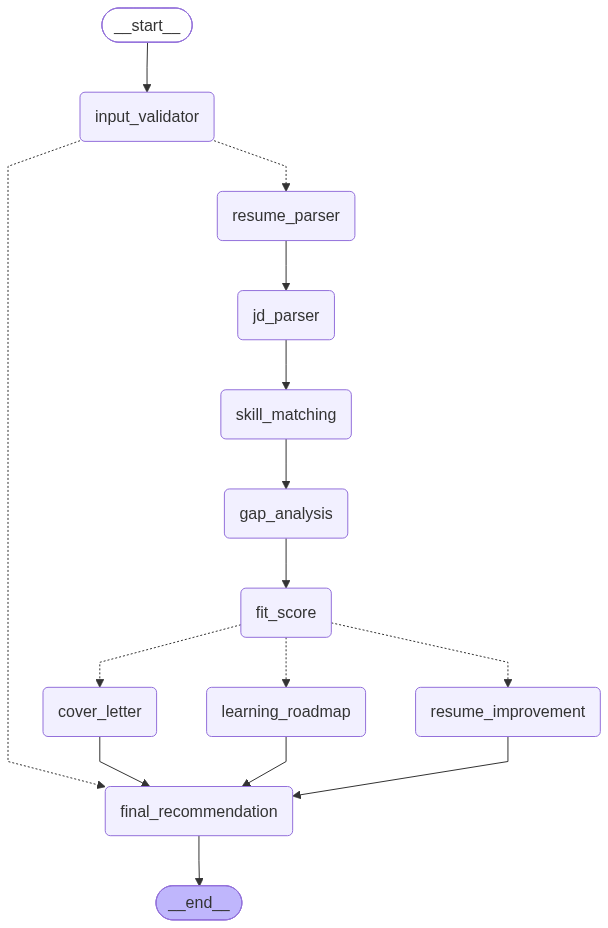

In [16]:
try:
    from IPython.display import Image, display

    display(Image(build_agent().get_graph().draw_mermaid_png()))
except Exception:
    print(build_agent().get_graph().draw_mermaid())

## Task 8 -- Test against three job descriptions

One resume, three adverts. The resume never changes, so every difference in the score is
produced by the job description alone.

Expect the SAP BTP AI role to score highest, and the two non-SAP roles to fall into the
weak-fit branch. The exact numbers depend on how Gemini sorts the skills, so treat them as a
target rather than a guarantee -- a score you disagree with is a prompt to sharpen
`MATCH_PROMPT` or the weights in `WEIGHTS`.

In [17]:
SAMPLE_RESUME = """
Prem Pratik
Senior SAP Consultant | 6 years of experience

Skills: SAP BTP, SAP HANA Cloud, Python, LangChain, LangGraph, RAG, GraphRAG,
SAP AI Core, SAP Generative AI Hub, CAP applications, SAP Build Process Automation,
prompt engineering, REST APIs, OData, SQL.

Projects:
- SAP GenAI Hub project: built a support automation agent on SAP AI Core and the
  Generative AI Hub that classifies incoming SAP incidents and drafts responses.
- GraphRAG project: knowledge graph over SAP documentation, queried through a
  LangChain retrieval pipeline for a code evaluation assistant.
- CAP service on SAP BTP exposing OData endpoints backed by SAP HANA Cloud.

Certifications: SAP Certified Associate - Business AI.
"""

JOB_DESCRIPTIONS = [
    (
        "SAP BTP AI Consultant",
        """
        We are hiring an SAP BTP AI Consultant with experience in SAP BTP, SAP AI Core,
        Joule, SAP Generative AI Hub, CAP, Integration Suite, HANA Cloud, and enterprise
        AI solution architecture. The candidate should understand GenAI, prompt
        engineering, RAG, and agentic AI workflows. Nice to have: LangChain, LangGraph,
        vector databases, and SAP Build Process Automation. 6+ years of experience.
        """,
    ),
    (
        "Data Engineer",
        """
        We are looking for a Data Engineer with strong Apache Spark, Apache Airflow, SQL,
        Python, ETL pipeline design, data modelling, Docker and Kubernetes experience.
        You will own batch and streaming pipelines on a cloud data platform and manage
        warehouse performance. Nice to have: dbt and Kafka. 4+ years of experience.
        """,
    ),
    (
        "SAP ABAP Developer",
        """
        We need an SAP ABAP Developer with deep ABAP, ABAP Cloud, RAP, S/4HANA, Fiori and
        OData experience. Responsibilities include building RAP business objects, custom
        Fiori applications, and clean-core extensions on S/4HANA. Nice to have: SAP BTP
        and CAP. 5+ years of experience.
        """,
    ),
]

In [18]:
app = build_agent()

results = []
for label, jd in JOB_DESCRIPTIONS:
    print("=" * 78)
    print(f"Screening against: {label}")
    print("=" * 78)
    state = run_agent(SAMPLE_RESUME, jd, app=app)
    print(format_report(state))
    print()
    results.append((label, state))

print("=" * 78)
print("Same resume, three roles")
print("=" * 78)
print(f"{'Role':<26}{'Score':<8}{'Fit Level':<24}Branch taken")
print("-" * 78)
for label, state in results:
    print(f"{label:<26}{str(state['fit_score']) + '/100':<8}"
          f"{state['fit_level']:<24}{branch_taken(state)}")

Screening against: SAP BTP AI Consultant
Candidate Fit Report
Candidate  : Prem Pratik (6 years)
Role       : SAP BTP AI Consultant (asks for 6+ years)
Fit Score  : 81/100
Fit Level  : Strong Fit
Verdict    : Apply now

Score breakdown:
  Core Technical         30
  Sap Btp Experience     14
  Genai Experience       17
  Project Relevance      10
  Consulting Fit         10

Matched Skills          : SAP BTP, SAP AI Core, SAP Generative AI Hub, SAP CAP, SAP HANA Cloud, Generative AI, Prompt Engineering, RAG
Partially Matched       : enterprise AI solution architecture, agentic AI workflows
Missing Skills          : SAP Joule, SAP Integration Suite

Gap Analysis:
The gaps in your profile are relatively minor and should not prevent you from securing an interview, as your core technical foundation is strong. The absence of SAP Joule is purely cosmetic, as your hands-on experience with SAP AI Core and the Generative AI Hub demonstrates that you already possess the underlying skills require

## Task 9 (extension) -- Memory

Three roles, one `thread_id`. The checkpointer restores the stored state before each run, and
the `operator.add` reducer on `history` keeps every job title -- which is the "save previous
job descriptions and compare roles" extension from section 12.

In [20]:
remembering = build_agent(memory=True)

for _, jd in JOB_DESCRIPTIONS:
    state = run_agent(SAMPLE_RESUME, jd, app=remembering, thread_id="candidate-prem")
    print(f"  {state['parsed_jd']['job_title']:<26}{state['fit_score']}/100")

print("\nRoles screened on thread candidate-prem:")
for n, role in enumerate(state["history"], start=1):
    print(f"  {n}. {role}")

  SAP BTP AI Consultant     81/100
  Data Engineer             16/100
  SAP ABAP Developer        17/100

Roles screened on thread candidate-prem:
  1. SAP BTP AI Consultant
  2. Data Engineer
  3. SAP ABAP Developer


## Task 10 (extension) -- Prove the validator branch

The happy path never touches `route_after_validation`. Send in an empty job description and
the graph should skip all six analysis nodes and land straight on `final_recommendation` --
no API call, no hallucinated candidate.

In [ ]:
state = run_agent(SAMPLE_RESUME, "", app=app)

print("Missing information :", state["missing_information"])
print("Branch taken        :", branch_taken(state))
print("Parsed resume       :", state.get("parsed_resume"))
print()
print(format_report(state))

## Where to take it next

- **Human in the loop** -- pause before the recruiter message and ask for approval, using
  LangGraph's `interrupt()` so the graph resumes from the checkpoint.
- **Real resumes** -- read a PDF with `pypdf` and feed the extracted text to `run_agent`.
- **Score the preferred skills too** -- they are parsed but currently only inform the match.
- **Tool calling** -- let Gemini pick the tools with `ToolNode` + `tools_condition` instead of
  fixed nodes; `MATCH_TOOLS` already exports them as LangChain tools.
- **Loop back** -- feed the resume improvements into a second screening run and check whether
  the score actually moves. That is the closest thing to a self-improving agent here.